In [1]:
%%capture
!pip install osmnx
!pip install geopandas

#!pip install dask_geopandas
!pip install branca;
!pip install folium;
!pip install mapclassify;
!pip install h3;
!pip install h3pandas;
!pip install bokeh;

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

import dask.dataframe as dd
from dask.diagnostics import ProgressBar

import h3
from shapely.geometry import shape

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
import seaborn as sns

from bokeh.plotting import output_notebook, show

from IPython.display import HTML

from report_plot_utils import plot_map_gdf, plot_time_series, plot_zscore_by_spatial_feature

mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["legend.frameon"] = False

pd.set_option("display.max_columns", None)

In [3]:
import h3
from shapely.geometry import shape

In [4]:
def gdf_to_h3(gdf, resolution):
    """
    Convert a GeoDataFrame of polygons to Uber H3 cells at a given resolution.
    """
    # ensure in lat/lon
    gdf = gdf.to_crs(epsg=4326)

    # collect unique H3 cell ids covering all input geometries
    h3_ids = set()
    for geom in gdf.geometry:
        cells = h3.geo_to_cells(geom, resolution)
        h3_ids.update(cells)

    # convert H3 cells to geojson‑style and then to Shapely polygons
    hex_geoms = []
    hex_ids = []
    for h in h3_ids:
        # cells_to_geo returns a __geo_interface__‑like dict for the cell(s)
        geojson = h3.cells_to_geo([h])
        # shape(...) converts geojson dict to shapely geometry
        poly = shape(geojson)
        hex_geoms.append(poly)
        hex_ids.append(h)

    # make GeoDataFrame
    h3_gdf = gpd.GeoDataFrame(
        {"h3_index": hex_ids},
        geometry=hex_geoms,
        crs="EPSG:4326"
    )

    return h3_gdf

In [5]:
def fill_time_gaps(x, y, freq="D"):
    # convert to pandas objects
    x = pd.to_datetime(x)
    y = np.asarray(y)

    # build series
    s = pd.Series(y, index=x)

    # full date range
    full_index = pd.date_range(start=s.index.min(),end=s.index.max(),freq=freq)

    # reindex -> missing dates become NaN
    s_filled = s.reindex(full_index)

    return s_filled.index, s_filled.values

# Urban Activity Dynamics During Flooding Events in Manila

In this case study, we apply our methodology to anonymized mobility data from Veraset to assess the impact of an extreme weather event on urban activity patterns in Metro Manila. Specifically, we examine **intense rainfall and flooding associated with the southwest monsoon (habagat), significantly enhanced by Typhoon Doksuri (locally known as Egay)**.

Typhoon Doksuri was one of the strongest tropical cyclones of 2023, causing widespread damage across Southeast and East Asia, particularly in the Philippines. In the country, over 2.9 million people were affected and at least 27 deaths were reported, underscoring its significant human and infrastructural impact ([Asian Disaster Reduction Center](https://www.adrc.asia/view_disaster_en.php?Lang=en&Key=2623)). Although the typhoon did not directly strike Metro Manila, it played a critical role in **intensifying the southwest monsoon**, resulting in **prolonged heavy rainfall, widespread flooding, and major disruptions to mobility and infrastructure** in the capital ([ReliefWeb](https://reliefweb.int/report/philippines/philippines-flooding-landslides-storms-and-winds-combined-effects-southwest-monsoon-and-tc-doksuri-29-jul-2023)).

News reports highlight the severity of the event and its cascading impacts. Heavy rainfall and flooding led to **widespread transport disruptions and power outages** ([Reuters](https://www.reuters.com/business/environment/thousands-without-power-typhoon-doksuri-lashes-philippines-2023-07-26/)), while tragic incidents such as a **boat capsizing near Manila** underscored the risks associated with extreme weather conditions ([ABC News](https://www.abc.net.au/news/2023-07-28/boat-capsizes-near-philippines-manila-killing-19/102659298)). Authorities implemented **preventive measures including the suspension of work and classes in Metro Manila** ([ABS-CBN](https://www.abs-cbn.com/news/07/22/23/marcos-suspends-govt-work-classes-on-july-24-due-to-egay-transport-strike)), and **flight cancellations and transport disruptions** were reported across multiple days ([Philstar](https://www.philstar.com/headlines/2023/07/24/2283409/list-canceled-flights-july-24-due-egay)).

Understanding how populations move and use urban spaces during extreme weather events is essential for informing disaster response, guiding resilient infrastructure design, and mitigating urban climate risk. In particular, flooding events represent a critical stress test for urban systems, as they directly affect **accessibility, mobility patterns, and the spatial distribution of human activity**.

We focus on the period between July 23 and July 28, 2023. Using the Urban Space Usage Index, we quantify deviations from typical activity patterns and analyze how different parts of the city respond to the evolving impacts of these conditions.

## 1. Data

### 1.1 Mobility Dataset
The analysis is based on the **[Veraset Movement dataset](https://docs.datapartnership.org/partners/veraset/examples/veraset.html)**, provided by Veraset as part of the Mobility Data collection from the Development Data Partnership. The dataset consists of anonymized mobile device location pings collected via a network of mobile applications and software development kits (SDKs). Each record includes geographic coordinates, a timestamp, and an anonymized device identifier. These data provide large-scale observations of human mobility, enabling the analysis of spatial and temporal patterns of urban activity.

In [6]:
SCENARIO = "FLOODS_DOKSURI"
H3_res = 8

dataset_name = f"dataset_{SCENARIO}"
FROM_DATE = pd.to_datetime("2023-07-14")
TO_DATE = pd.to_datetime("2023-07-28")

### 1.2 Area of Interest (AOI)

The analysis focuses on the metropolitan area of Manila (Metro Manila), the capital region of the Philippines. The study area is defined using administrative boundaries extracted from OpenStreetMap (OSM) (Figure 1).

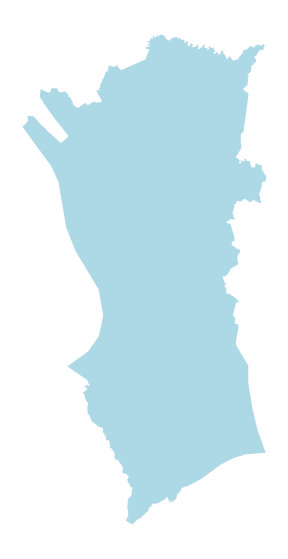

In [7]:
# AOI

gdf_AOI = gpd.read_file("./shape_files/shape_metro_manila.gpkg")

minx, miny, maxx, maxy = gdf_AOI.total_bounds
fig, ax = plt.subplots(figsize=(5,7))
gdf_AOI.plot(ax=ax, color='lightblue', edgecolor=None)
ax.axis("off");

**Figure 1.** Administrative boundary of the metropolitan area of Manila (Metro Manila), used to define the area of interest (AOI). All mobility data are spatially clipped to this region and aggregated using the H3 hierarchical grid system.

**Create (or load, if exists) the H3 spatial tessellation of the AOI**

| Res | Average Hexagon Area (km²) |
|-----|----------------------------|
| ... | ...                        |
| 6   | 36.129062164               |
| 7   | 5.161293360                |
| 8   | 0.737327598                |
| 9   | 0.105332513                |
| ... | ...                        |

In [8]:
H3_res = 8

In [9]:
output_path = Path(f"./spatial_tessellations/gdf_h3_res8_manila.gpkg")

if output_path.exists():
    print("File exists. Loading...")
    gdf_h3 = gpd.read_file(output_path)
else:
    print("File not found. Computing and saving...")
    crs = gdf_AOI.crs
    gdf_h3 = gdf_to_h3(
        gdf_AOI.buffer(0.03).to_crs(crs),
        H3_res
    )
    print(len(gdf_h3))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    gdf_h3.to_file(output_path, driver="GPKG")

File exists. Loading...


We spatially discretized the area of interest using the H3 Uber hierarchical indexing at resolution 8, corresponding to hexagonal cells of approximately 0.737 km². Each H3 cell (or hexagon) represents the spatial unit of the analysis.

<Axes: >

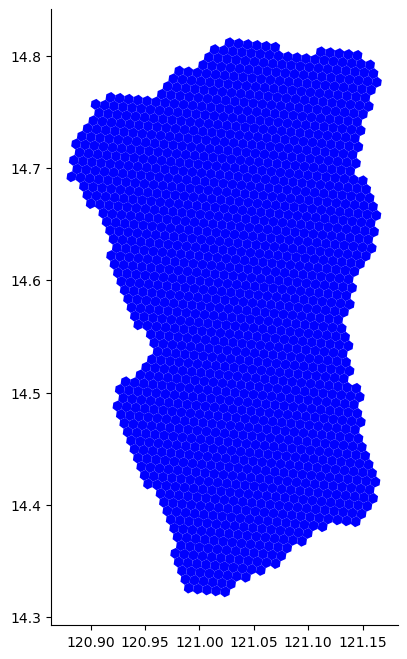

In [10]:
fig, ax = plt.subplots(figsize=(8,8))
gdf_h3.plot(color="blue", ax=ax, label="new")

### 1.3 Time window and study periods
To capture mobility and activity dynamics associated with monsoon-driven rainfall and flooding conditions enhanced by Typhoon Doksuri, we extract data covering the period from July 14 to July 28, 2023, spatially restricted to the study area. 

The analysis cannot be extended beyond July 28 due to a data quality issue identified in {doc}`Manila_EDA_QA`. Starting from July 29, there is a marked decline in both the number of GPS observations per hexagon and the number of active users per hexagon, which may affect the reliability of the results. For this reason, the analysis is limited to data up to July 28 to avoid potential misinterpretation. 

We define two analysis periods:
- **Baseline period**: July 14-22
- **Event period**:  July 24-28

July 23 is excluded from both periods and treated as a buffer day, to avoid contamination from early behavioral responses to the approaching event. The extracted dataset consists of approximately **218 million GPS points** generated by **7.5 million unique users**.

In [13]:
time_window = pd.date_range(start=FROM_DATE, end=TO_DATE, freq="D")

# Print summary
print(f"Loading data from {min(time_window):%Y-%m-%d} to {max(time_window):%Y-%m-%d}")
print(f"Time window length: {len(time_window)} days")

Loading data from 2023-07-14 to 2023-07-28
Time window length: 15 days


### Data Loading

In [14]:
dataset_name = SCENARIO

path_base = f"s3://wbgggscecovid19dev-mobility/veraset/country=PH"
base_path_save = f"s3://wbgggscecovid19dev-mobility/proposals/561/datasets/"
path_save = f'{base_path_save}{dataset_name}/'

print(path_save)

s3://wbgggscecovid19dev-mobility/proposals/561/datasets/FLOODS_DOKSURI/


#### Raw-Data Preparation and Loading (slow)

_loading time $\approx$ XXX mins for 90 days_

Load from scratch the dataset covering the baseline, event, and recovery periods using **Dask**.  
Apply spatial filtering to reduce the dataset to the Area of Interest (AOI).  
If the filtered subset is small enough to fit in memory, convert it to **Pandas** for faster aggregation and analysis.

In [12]:
FROM_DATE = min(time_window)
TO_DATE = max(time_window)

print(FROM_DATE, TO_DATE, sep="   -   ")

NameError: name 'time_window' is not defined

In [ ]:
paths_to_load = [path_base+f"/year={d.year}/date={d.strftime('%Y-%m-%d')}/*.parquet" for d in time_window]
len(paths_to_load)

In [ ]:
### Data Loading

path_base = f"s3://wbgggscecovid19dev-mobility/veraset/country=TR"
base_path_save = f"s3://wbgggscecovid19dev-mobility/proposals/561/datasets/"
path_save = f'{base_path_save}{dataset_name}/'

print(path_save)

In [ ]:
%%time

# -------------------------
# 0. Load raw GPS dataset (lazy)
columns = ['uid', 'datetime', 'hex_id', 'latitude', 'longitude']
ddf = dd.read_parquet(paths_to_load,  engine="pyarrow", columns=columns, storage_options={"profile": "ECA"})

# 1. Bounding box filter
ddf = ddf[(ddf.longitude >= minx) & (ddf.longitude <= maxx) &
    (ddf.latitude  >= miny) & (ddf.latitude  <= maxy)]

# -------------------------
# 2. Process datetime (lazy)
ddf['local_datetime'] = (
    dd.to_datetime(ddf['datetime'], utc=True)
      .dt.tz_convert('Asia/Manila')
      .dt.tz_localize(None)
)

# re-add this
ddf = ddf[(ddf['local_datetime'] >= FROM_DATE) & (ddf['local_datetime'] <= TO_DATE + pd.Timedelta(days=1))]
ddf['date'] = ddf['local_datetime'].dt.floor('D')

In [ ]:
with ProgressBar():
    df = ddf.compute()

#### Hybrid

In [ ]:
with ProgressBar():

    ddf.to_parquet(
    path_save,
    write_index=False,
    engine="pyarrow",
    storage_options={'profile': 'ECA'}
)

In [ ]:
with ProgressBar():
    df = ddf.compute()

df = df[df["date"]<=max(time_window)]

print("# rows:", len(df))

# Memory usage
mem_bytes = df.memory_usage(deep=True).sum()
mem_gb = mem_bytes / (1024**3)
print(f"{mem_gb:.2f} GB")

# Save the dataset for future (faster) loading
ddf_to_save = dd.from_pandas(df)
ddf_to_save.to_parquet(path_save,
                       write_index=False,
                       engine="pyarrow",
                       storage_options= {'profile':'ECA'})

#### Full dask

In [ ]:
with ProgressBar():
    ddf.to_parquet(
            path_save,
            write_index=False,
            engine="pyarrow",
            storage_options={'profile': 'ECA'}
        )

In [ ]:
!aws s3 ls --profile ECA s3://wbgggscecovid19dev-mobility/proposals/561/datasets/

___

#### Load pre-computed Dataset (fast)

_loading time $\approx$ 2 min for pre-computed 30 days_

In [15]:
paths_to_load = ["s3://wbgggscecovid19dev-mobility/proposals/561/datasets/FLOODS_DOKSURI/*.parquet"]

In [16]:
FROM_DATE, TO_DATE + pd.Timedelta(days=1)

(Timestamp('2023-07-14 00:00:00'), Timestamp('2023-07-29 00:00:00'))

In [17]:
ddf = dd.read_parquet(paths_to_load, engine="pyarrow",
                      storage_options={"profile": "ECA"},
                      columns=["uid", "latitude", "longitude", "date"])

ddf = ddf[(ddf['date'] >= FROM_DATE)&(ddf['date'] < TO_DATE + pd.Timedelta(days=1))]

#ddf = ddf.repartition(partition_size="200MB")

In [18]:
with ProgressBar():
    df = ddf.compute()

[########################################] | 100% Completed | 221.73 s


In [19]:
# Basic cleaning and memory stats

df = df[["uid", "latitude", "longitude", "date"]]

print("# rows:", len(df))
print("# users:", df["uid"].nunique())
# Memory usage
mem_bytes = df.memory_usage(deep=True).sum()
mem_gb = mem_bytes / (1024**3)
print(f"{mem_gb:.2f} GB")

# rows: 252832744
# users: 8728788
22.66 GB


In [22]:
from multiprocessing import Pool, cpu_count
import numpy as np

In [23]:
%%time

def process_chunk(chunk):
    lat_chunk, lng_chunk = chunk
    return [h3.latlng_to_cell(la, lo, H3_res) for la, lo in zip(lat_chunk, lng_chunk)]

lat = df["latitude"].to_numpy()
lng = df["longitude"].to_numpy()

chunks = 8 * cpu_count()  # tune this
lat_splits = np.array_split(lat, chunks)
lng_splits = np.array_split(lng, chunks)

with Pool(cpu_count()) as p:
    results = p.map(process_chunk, zip(lat_splits, lng_splits))

list_h3_cell_ids = [item for sublist in results for item in sublist]

CPU times: user 27 s, sys: 23.7 s, total: 50.7 s
Wall time: 50.6 s


In [24]:
df["hex_id"] = list_h3_cell_ids
del list_h3_cell_ids

In [25]:
del lat
del lng
del lat_splits
del lng_splits

In [26]:
import gc
gc.collect()

51399

In [27]:
df.drop(["latitude", "longitude"], axis=1, inplace=True)

In [28]:
gc.collect()

0

#### Spatial Filtering

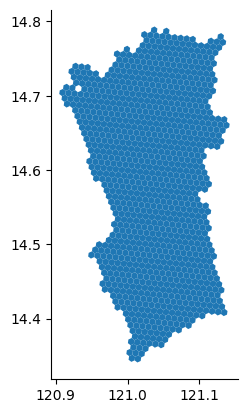

In [29]:
gdf_h3_AOI = gpd.sjoin(gdf_h3, gdf_AOI, how="inner", predicate="intersects")
gdf_h3_AOI.plot();

In [30]:
gdf_h3_AOI[:1]

,h3_index,geometry,index_right
1,88694ed6e7fffff,"POLYGON ((121.08143 14.77176, 121.07758 14.774...",0


In [ ]:
# set-based filtering
#set_h3_AOI = set(gdf_h3_AOI["h3_index"])
#df_AOI = df[df["hex_id"].isin(set_h3_AOI)]

In [31]:
df_AOI = df.merge(gdf_h3_AOI[["h3_index"]], 
                  left_on="hex_id", 
                  right_on="h3_index", 
                  how="inner")

Visualize the map **BEFORE** and **AFTER** the spatial filtering

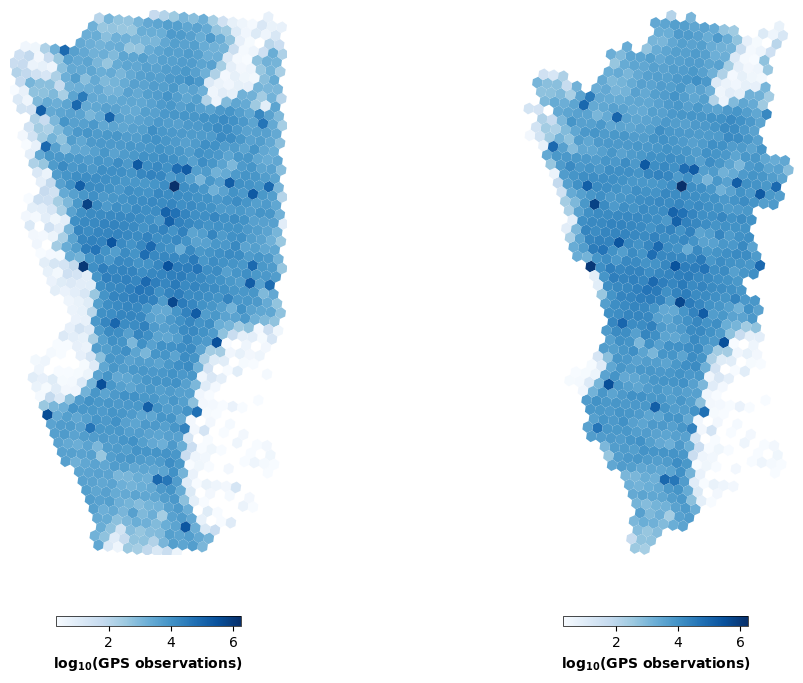

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12,8))

# Get global bounds from the full hex grid
xmin, ymin, xmax, ymax = gdf_h3_AOI.total_bounds

for ax, dplot in zip(axes, [df, df_AOI]):
    df_gb_count = dplot.groupby(["hex_id", "date"], as_index=False).count()[["hex_id", "uid"]]
    df_hex_avg_points_day = df_gb_count.groupby("hex_id", as_index=False).mean()
    gdf_map = gdf_h3.merge(df_hex_avg_points_day, left_on="h3_index", right_on="hex_id", how="left")
    gdf_map["uid"] = gdf_map["uid"].fillna(0)
    _, _, cbar = plot_map_gdf(gdf_map, col="uid", cmap="Blues", ax=ax, fig=fig)
    
    ax.axis("off");
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    cbar.set_label(r"$\mathbf{log_{10}}$(GPS observations)", weight=600)
    cbar.outline.set_linewidth(0.5) 

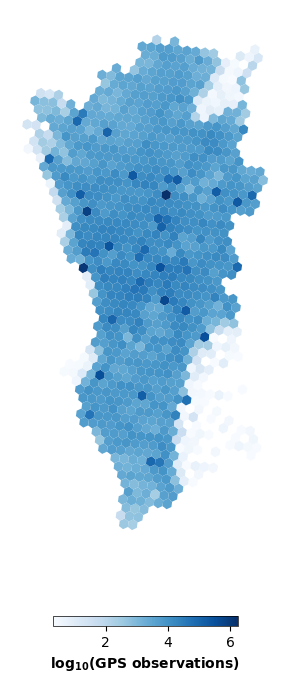

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(12,8))


df_gb_count = df_AOI.groupby(["hex_id", "date"], as_index=False).count()[["hex_id", "uid"]]
df_hex_avg_points_day = df_gb_count.groupby("hex_id", as_index=False).mean()
gdf_map = gdf_h3.merge(df_hex_avg_points_day, left_on="h3_index", right_on="hex_id", how="left")
gdf_map["uid"] = gdf_map["uid"].fillna(0)
_, _, cbar = plot_map_gdf(gdf_map, col="uid", cmap="Blues", ax=ax, fig=fig)

ax.axis("off");
#ax.set_xlim(xmin, xmax)
#ax.set_ylim(ymin, ymax)

cbar.set_label(r"$\mathbf{log_{10}}$(GPS observations)", weight=600)
cbar.outline.set_linewidth(0.5) 

**Figure 2.** Spatial distribution of GPS observations shown as the average number of records per H3 hexagon (resolution 8). Higher values represent a greater concentration of recorded activity. The color scale is log₁₀-transformed, with darker blue tones indicating areas with more observations.

In [34]:
df_AOI = df_AOI[["uid", "hex_id", "date"]]

print("# rows:", len(df_AOI))
print("# users:", df_AOI["uid"].nunique())
# Memory usage
mem_bytes = df_AOI.memory_usage(deep=True).sum()
mem_gb = mem_bytes / (1024**3)
print(f"{mem_gb:.2f} GB")

# rows: 218557619
# users: 7561811
29.34 GB


In [35]:
del df
import gc
gc.collect()

5142

In [36]:
del df_gb_count

In [37]:
gc.collect()

0

### 1.4 Preprocessing and filtering

To ensure data quality and reduce noise, we apply a set of preprocessing steps. Users with very low daily activity (fewer than eight recorded points per day) are excluded, as they do not provide reliable information on spatial behavior. As shown in Figure 3, increasing the minimum points-per-day threshold progressively removes low-activity users and reduces sharp spikes driven by users with only one or very few daily points, while preserving broadly consistent temporal trends across filtering levels.

In addition, H3 hexagons are retained only if they are consistently active throughout the observation period. Hexes with insufficient activity are removed to avoid unstable estimates and inflated Z-scores.

The final dataset consists of 202,800,033 observations from 4,350,596 users covering 868 spatial units.

In [ ]:
# Time series: Total Points, Unique Users, and Visited Hexes per Day

df_gb_stats_raw = (
    df_AOI.groupby("date")
      .agg(n_points_count=("uid", "count"), uid_unique=("uid", "nunique"),
           hex_id_unique=("hex_id", "nunique")).reset_index())

In [ ]:
axes_ts = plot_time_series(df_gb_stats_raw, axes=None, color="k", plot_avg=False)
for ax in axes_ts:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    ax.set_xlabel("Date", weight=600)
    #ax.set_xlim(None, pd.to_datetime("2023-04-30"))

In [ ]:
list_gps_user_day = list(df_AOI.groupby(['uid', 'date']).size().reset_index(name='n_obs')["n_obs"])

print("--- Number of observations per user per day ---")
print("avg. ", round(np.mean(list_gps_user_day),2))
print("Q1", np.quantile(list_gps_user_day, .25))
print("median", np.quantile(list_gps_user_day, .5))
print("Q3", np.quantile(list_gps_user_day, .75))

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.kdeplot(list_gps_user_day, clip=[0, None], c="k", linewidth=1)

p25 = np.quantile(list_gps_user_day, 0.25)
p50 = np.quantile(list_gps_user_day, 0.5)
p75 = np.quantile(list_gps_user_day, 0.75)

for p, label in zip([p25, p50, p75], ["25th", "50th", "75th"]):
    plt.axvline(p, c="grey", linestyle="--", linewidth=1)
    # Annotate the percentile near the line
    plt.text(p, plt.ylim()[1], f"{label}", rotation=0, color='k', fontsize=8)

plt.xscale("log")
ax.set_xlabel("Number of observations / day", weight=600)
ax.set_ylabel("Density", weight=600);

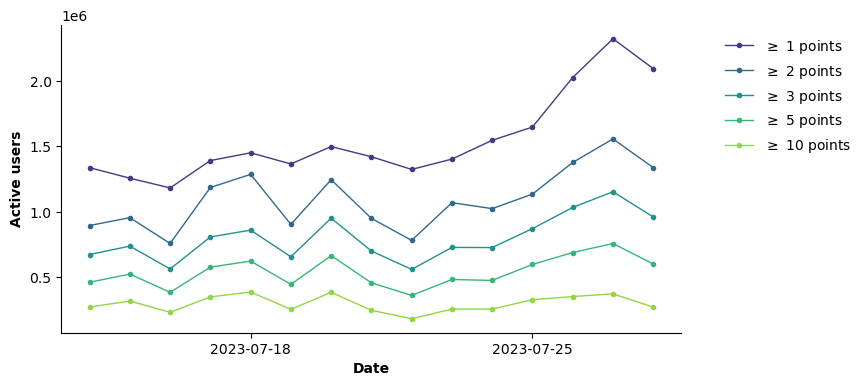

In [38]:
# number of users at different thresholds

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 4), sharex=False)

user_min_points = [1, 2, 3, 5, 10]

palette = sns.color_palette("viridis", n_colors=len(user_min_points))

for user_th, col in zip(user_min_points, palette):

    df_filtered_u = df_AOI[df_AOI.groupby(['uid', 'date'])['uid'].transform('count') >= user_th]
    
    df_gb_stats_filtered = (
    df_filtered_u.groupby("date")
              .agg(
                  n_points_count=("uid", "count"),uid_unique=("uid", "nunique"),
                  hex_id_unique=("hex_id", "nunique")).reset_index())

    del df_filtered_u
    ax.plot(df_gb_stats_filtered["date"], df_gb_stats_filtered["uid_unique"], c=col, linewidth=1, marker=".", label=f"$\geq$ {user_th} points")
 

ax.set_xlabel("Date", weight=600);
ax.set_ylabel("Active users", weight=600);
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.legend(bbox_to_anchor=(1.05, 1));

**Figure 3.** Daily number of active users retained under different minimum points-per-day thresholds ($\geq$ 1,2,3,5, and 10 points). Increasing the threshold progressively removes low-activity users, reducing sharp spikes driven by users with only one or very few daily points, while preserving temporal trends.

## 2. Methods

The analysis follows the methodological framework described in {doc}`Methodology` and applied in the previous case study. In brief, we use the **Urban Space Usage Index** ($I$), defined as the **share of unique users visiting each H3 hexagon**. The number of unique users is used as a proxy for human presence, under the assumption that higher user counts correspond to greater spatial utilization.

To **quantify deviations** from typical conditions, we compute **Z-scores**, which measure how strongly observed activity deviates from baseline levels. Positive values indicate higher activity, while negative values indicate lower activity compared to baseline conditions.

**Filter 1:** Remove users per day who do not meet the minimum number of GPS points threshold (noise users).

In [39]:
# filtering parameters

# tip: we can use the median value, it seems robust to me
min_points_per_day = 3

df_filtered_u = df_AOI[df_AOI.groupby(['uid', 'date'])['uid'].transform('count') >= min_points_per_day]

print(f"min points/day: {min_points_per_day}")
print(f"# GPS points: {len(df_filtered_u)} ({len(df_AOI)-len(df_filtered_u)} points removed)")
print("# unique users", df_filtered_u["uid"].nunique())

min points/day: 3
# GPS points: 202805507 (15752112 points removed)
# unique users 4350675


Compute the Urban Space Index
- each **row** is an **hex**
- each **column** refers to a **day**
- each cell is the number of unique users that visit an hex on a given day (ACTIVITY)

In [40]:
ts_ACTIVITY = df_filtered_u.groupby(["hex_id", "date"])["uid"].nunique().unstack(fill_value=0)
ts_ACTIVITY[:3]

date,2023-07-14,2023-07-15,2023-07-16,2023-07-17,2023-07-18,2023-07-19,2023-07-20,2023-07-21,2023-07-22,2023-07-23,2023-07-24,2023-07-25,2023-07-26,2023-07-27,2023-07-28
hex_id,,,,,,,,,,,,,,,
88694e5201fffff,11,21,24,22,14,17,19,17,18,27,23,25,16,15,13
88694e5203fffff,954,1081,991,783,843,784,764,621,603,820,780,965,641,585,347
88694e5205fffff,41,40,45,35,50,44,51,35,37,47,41,44,49,42,28


In [41]:
ts_ACTIVITY.shape

(981, 15)


Filter 2: Remove hexes that do not meet the minimum activity threshold across a sufficient share of days.

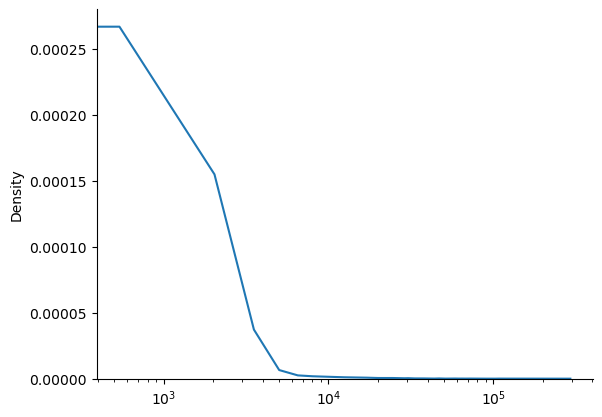

In [42]:
values_list = ts_ACTIVITY.to_numpy().ravel().tolist()
sns.kdeplot(values_list)
plt.xscale("log")

In [43]:
k = 0                   # minimum observations per day
x_percent = 0.95        # e.g., x% of days required

# total number of days (columns)
total_days = ts_ACTIVITY.shape[1]

# minimum number of valid days required
min_days_required = x_percent * total_days

# count how many days per hex exceed k
valid_days_per_hex = (ts_ACTIVITY > k).sum(axis=1)

# filter
hexes_to_keep = set(ts_ACTIVITY[valid_days_per_hex >= min_days_required].index)
ts_ACTIVITY_filtered = ts_ACTIVITY[ts_ACTIVITY.index.isin(hexes_to_keep)]

print("total number of hexes:", len(ts_ACTIVITY_filtered))
print("removed hexes:", len(ts_ACTIVITY) - len(ts_ACTIVITY_filtered))

total number of hexes: 868
removed hexes: 113


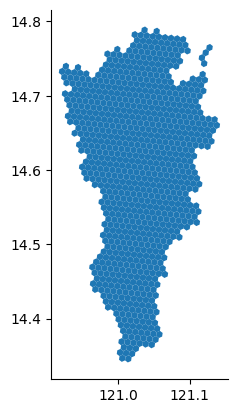

In [44]:
gdf_h3[gdf_h3["h3_index"].isin(ts_ACTIVITY_filtered.index)].plot()
ax.axis("off");

In [45]:
G = set(ts_ACTIVITY_filtered.index)

In [46]:
len(df_filtered_u[df_filtered_u["hex_id"].isin(G)])

202800033

In [47]:
df_filtered_u[df_filtered_u["hex_id"].isin(G)]["uid"].nunique()

4350596

In [48]:
df_filtered_u[df_filtered_u["hex_id"].isin(G)]["hex_id"].nunique()

868

**Compute the number of unique users that visit an hex on a given day (to normalize ACTIVITY)**

In [49]:
total_unique_users = df_filtered_u.groupby("date")["uid"].nunique()
ts_USI = ts_ACTIVITY_filtered / total_unique_users

ts_USI[:1]

date,2023-07-14,2023-07-15,2023-07-16,2023-07-17,2023-07-18,2023-07-19,2023-07-20,2023-07-21,2023-07-22,2023-07-23,2023-07-24,2023-07-25,2023-07-26,2023-07-27,2023-07-28
hex_id,,,,,,,,,,,,,,,
88694e5201fffff,0.000016,0.000028,0.000043,0.000027,0.000016,0.000026,0.00002,0.000024,0.000032,0.000037,0.000032,0.000029,0.000015,0.000013,0.000014


In [50]:
ts_USI = ts_USI.loc[:, "2023-07-14":"2023-07-28"]

## 3. Results

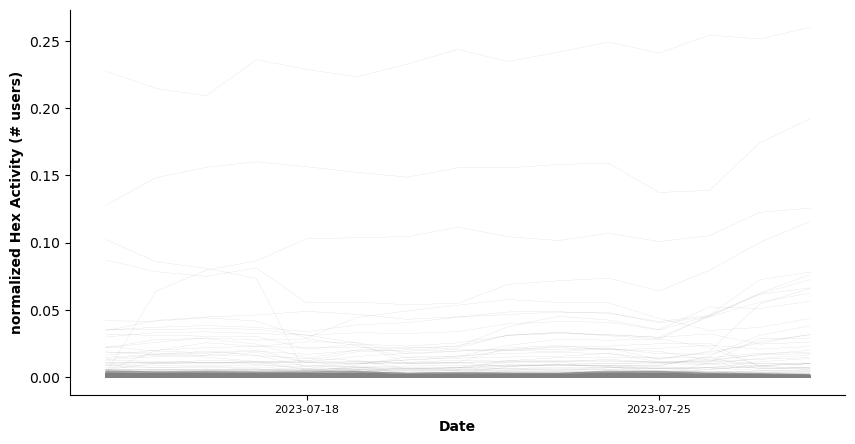

In [51]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

for hex_id in ts_USI.index:
    ax.plot(ts_USI.columns, ts_USI.loc[hex_id], alpha=0.6, linewidth=0.1, color="grey")

ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("normalized Hex Activity (# users)", weight=600);
#plt.ylim(0, 200);

### 3.1 Temporal evolution of urban activity

The temporal evolution of the Urban Space Usage Index ($I$) shows relatively stable activity levels during the baseline period (July 14-22), with moderate day-to-day variability captured by the interquartile range (Figure 4). 

As the event approaches, activity slightly increases during the **onset phase (July 24-25)**, likely reflecting **anticipatory behaviors**, such as stocking essential goods or short-distance relocation. 
Starting from July 26, corresponding to the **intensification of rainfall and flooding conditions**, $I$ exhibits a marked decline, which continues through July 27-28, indicating a sustained reduction in urban activity. 
Overall, the temporal pattern reveals a progressive disruption of urban activity, characterized by a brief pre-impact increase followed by a pronounced decrease during the **peak flooding phase**, when mobility is most constrained. 

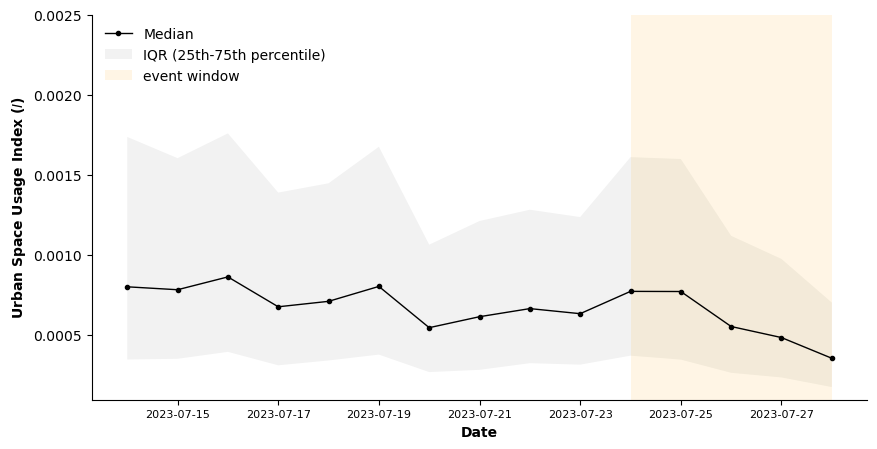

In [52]:
# Calculate the mean and IQR
median_values = ts_USI.median(axis=0)
q25 = ts_USI.quantile(0.25, axis=0)
q75 = ts_USI.quantile(0.75, axis=0)

# Create the plot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

# Plot the mean line
ax.plot(ts_USI.columns, median_values, c="k", label="Median", linewidth=1, marker=".")

# Plot the shaded area for the IQR
ax.fill_between(ts_USI.columns, q25, q75, color="grey", alpha=0.1, label="IQR (25th-75th percentile)", edgecolor="none")

#ax.axhline(ts_USI.loc[:, "2023-04-03":"2023-04-11"].mean().mean(), color="k", linewidth=0.4, linestyle="--", label="Mean $I$ (baseline)")

ax.axvspan(pd.to_datetime("2023-07-24 00:00"), pd.to_datetime("2023-07-28 00:00"), color="orange", alpha=0.1, linewidth=0, label="event window")
#ax.axvspan(pd.to_datetime("2023-6-22 00:00"), pd.to_datetime("2023-06-22 23:59"), color="red", alpha=0.1, linewidth=0)


# Highlight the heatwave days
#hw_dates = pd.to_datetime(HW_days)
#hw_y_values = ts_USI[hw_dates].mean().values
#ax.scatter(hw_dates, hw_y_values, marker="*", color="red", s=50, zorder=99, label="Heatwave day")


# Format the x-axis (dates)
ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("Urban Space Usage Index ($I$)", weight=600)
ax.set_ylim(None, 0.0025)

#ax.set_xlim(pd.to_datetime("2023-07-21"), None)

# Add a legend
ax.legend();

**Figure 4.** Time series of the median Urban Space Usage Index ($I$) across all hexagonal cells in the area of interest, with the shaded area representing the interquartile range. The yellow shaded area highlights the event period associated with monsoon-driven rainfall and flooding conditions.

### 3.2 Anomaly detection

Figure 5 presents the temporal evolution of Z-scores, which quantify how many standard deviations observed activity deviates from baseline conditions. 

During the baseline period, Z-scores fluctuate around zero, indicating typical levels of activity. However, a negative deviation is observed on July 20. This anomaly likely coincides with an official Thunderstorm Watch issued for the Greater Metro Manila Area, warning of potential severe weather. Such advisories may have triggered precautionary behavioral responses, leading to reduced activity. 

As the event approaches (July 24-25), Z-scores become positive (0.58 and 0.43, respectively), indicating a temporary increase in activity relative to baseline levels, consistent with **anticipatory behaviors** such as stocking or short-distance relocation. 

From July 26 onward, corresponding to the **intensification of monsoon-driven rainfall and flooding conditions**, Z-scores drop to -1.32 on July 26 and -1.91 on July 27, reaching extreme anomaly levels by July 28 (Z = -3.03). This indicates a strong reduction in urban activity, consistent with widespread flooding, infrastructure disruption, and mobility constraints.

Due to data quality issues identified from July 29 onward, the evolution of Z-scores beyond this date cannot be reliably assessed. 

Overall, the Z-score dynamics confirm a **progressive transition from normal conditions to severe disruption**, with early increase in activity due to precautionary behaviours and a decrease during the most intense phase of the event. 

In [53]:
baseline = ts_USI.loc[:, "2023-07-14":"2023-07-22"]

baseline_mean = baseline.mean(axis=1)
baseline_std = baseline.std(axis=1)

In [54]:
# subtraction and division row-wise to compute the z-score

z_scores = ts_USI.sub(baseline_mean, axis=0).div(baseline_std, axis=0)
z_scores = z_scores.dropna()


z_scores = z_scores.loc[:, "2023-07-14":]
#z_scores.mean()

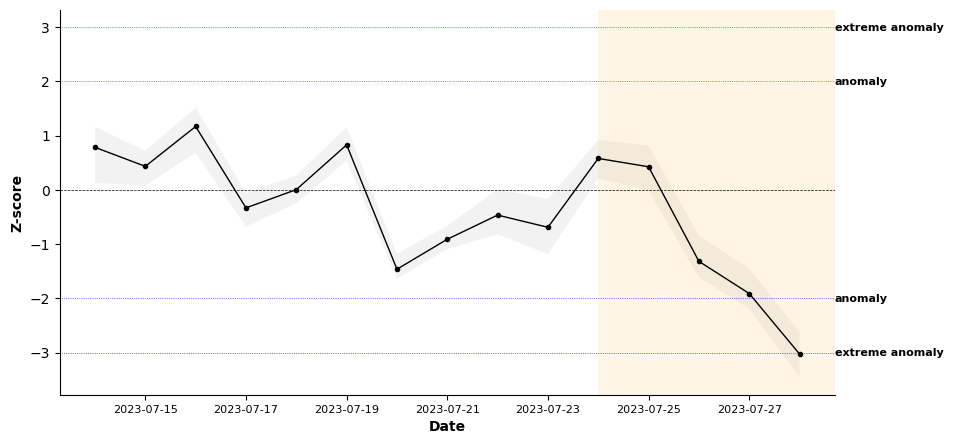

In [55]:
#z_score_filter_start = pd.to_datetime("2023-04-12")
#z_score_filter_end = pd.to_datetime("2023-04-19")

#z_scores = z_scores.loc[:, ~z_scores.columns.to_series().between(z_score_filter_start, z_score_filter_end)]

mean_values = z_scores.median(axis=0)
x_ax = z_scores.columns
x_ax, mean_values = fill_time_gaps(z_scores.columns, mean_values)

_, q25 = fill_time_gaps(z_scores.columns, z_scores.quantile(0.25, axis=0))
_, q75 = fill_time_gaps(z_scores.columns, z_scores.quantile(0.75, axis=0))

# Create the plot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5), sharex=False)

# Plot the mean line
ax.plot(x_ax, mean_values, c="k", linewidth=1, zorder=99, marker=".")  # average line

# Plot the shaded area for the IQR with no border
ax.fill_between(x_ax, q25, q75, color="grey", alpha=0.1, edgecolor="none", label="IQR (25th-75th percentile)")

# Add horizontal line at 0
ax.axhline(0, c="k", linewidth=.5, linestyle="--")

#ax.axvline(pd.to_datetime("2023-06-22"), c="red", linewidth=.5, linestyle="--")

x_lims = ax.set_xlim()

# --- Anomaly thresholds ---
for anomaly_th, anomaly_label in zip([2, 3], ["anomaly", "extreme anomaly"]):
    ax.axhline(anomaly_th, c="red", linewidth=.5, linestyle=":")
    ax.axhline(-anomaly_th, c="blue", linewidth=.5, linestyle=":")
    
    # Adding labels for anomalies
    plt.text(x_lims[1], anomaly_th, anomaly_label, ha="left", va="center", weight=600, size=8)
    plt.text(x_lims[1], -anomaly_th, anomaly_label, ha="left", va="center", weight=600, size=8)
    
    

# Format the x-axis (dates)
ax.tick_params(axis='x', labelsize=8)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel("Date", weight=600)
ax.set_ylabel("Z-score", weight=600)

ax.axvspan(pd.to_datetime("2023-07-24 00:00"), pd.to_datetime("2023-07-29 00:00"), color="orange", alpha=0.1, linewidth=0);


# Highlight the heatwave days
#hw_dates = pd.to_datetime(HW_days)
#hw_y_values = z_scores[hw_dates].mean().values
#ax.scatter(hw_dates, hw_y_values, marker="*", color="red", s=50, zorder=99, label="Heatwave day");

#plt.ylim(-4, 4);

In [56]:
pd.DataFrame(z_scores.median()).T

date,2023-07-14,2023-07-15,2023-07-16,2023-07-17,2023-07-18,2023-07-19,2023-07-20,2023-07-21,2023-07-22,2023-07-23,2023-07-24,2023-07-25,2023-07-26,2023-07-27,2023-07-28
0,0.784283,0.433556,1.169229,-0.332391,0.004553,0.830417,-1.463618,-0.910875,-0.465609,-0.690339,0.579901,0.426076,-1.318447,-1.911919,-3.028046


**Figure 5.** Time series of the average Z-score of the Urban Space Usage Index across hexagons in Metro Manila, with the shaded area representing the interquartile range. Horizontal dashed lines indicate anomaly thresholds. The yellow shaded area highlights the event period associated with monsoon-driven rainfall and flooding conditions.

### 3.3 Spatial distribution of anomalies

Figure 6 illustrates the spatial distribution of Z-scores across the study area on July 27, corresponding to the **peak flooding phase of the event**. The map shows a predominance of negative anomalies, indicating a widespread reduction in urban activity across most spatial units. A limited number of positive anomalies (red hexagons) are scattered across the area of interest. These localized increases in activity may reflect **spatial concentration effects**, potentially associated with emergency response operations or residential dynamics, where reduced mobility leads to increased presence and device activity in home locations. 

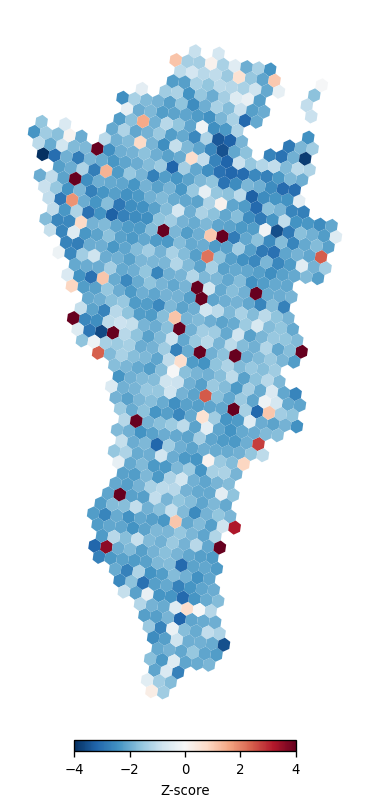

In [57]:
day_plot = "2023-07-27"

df_gdf_zscore = z_scores[[day_plot]].copy()
df_gdf_zscore["z_score"] = df_gdf_zscore[day_plot]
df_gdf_zscore_plot = df_gdf_zscore[["z_score"]]

vmax = 4
vmin =-vmax

gdf_map_zscore = gdf_h3.merge(df_gdf_zscore_plot, left_on="h3_index", right_on="hex_id", how="inner")

fig, ax = plt.subplots(figsize=(12,8), dpi=120)
gdf_map_zscore.plot(column="z_score", cmap="RdBu_r", legend=False, ax=ax, vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin, vmax))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.015, pad=0.01, orientation="horizontal")
cbar.set_label("Z-score", fontsize=8)
cbar.ax.tick_params(labelsize=8)
ax.axis("off");

**Figure 6.** Map of the Z-score of the Urban Space Usage Index across H3 hexagonal cells in Metro Manila on July 27, 2023. Warmer colors indicate higher-than-expected activity, while cooler colors indicate negative anomalies, showing a widespread reduction in activity during peak flooding conditions across the metropolitan area.

The interactive map (Figure 7) allows users to explore the full time series of Z-scores across the study area. This tool enables the examination of temporal dynamics at different locations, providing a more detailed and intuitive understanding of how activity patterns evolve over time. 


In [2]:
from IPython.display import HTML
HTML('<iframe width="100%" height="800px" src="https://studio.foursquare.com/map/public/001c75ff-245c-47be-b88f-e585b7bec842/embed" frameborder="0" allowfullscreen></iframe>')

**Figure 7.** Interactive map of the Z-score of the Urban Space Usage Index across H3 hexagonal cells in the area of interest. The animation shows the day-by-day evolution of activity levels, with colors indicating relative intensity.

### 3.4 Spatial and Functional Characterization of Activity

To interpret the spatial distribution of activity, each hexagonal cell is associated with both land use and functional activity. For land use, we assign each hexagon a dominant category (e.g., residential, commercial, industrial, green areas), capturing the physical organization of urban space. In contrast, the functional layer is derived from POIs: for each hexagon, we count the number of POIs in different activity categories (e.g., schools, hospitals, parks, transport hubs, commercial venues). For more details on the land use and functional activity methodology, refer to {doc}`Methodology_land_usage`.

Land-use and POI data are derived from OpenStreetMap (OSM) and accessed via Geofabrik extracts (https://download.geofabrik.de/asia/philippines.html). To ensure temporal consistency with the mobility data, which refer to 2023, we use OSM snapshots from January 2023. © OpenStreetMap contributors, licensed under the Open Database License (ODbL).

In [59]:
# loading the land use shapefile
gdf_h3_landuse = gpd.read_file(f"./land_usage/land_usage_h3_res8_metro_manila.gpkg")
gdf_h3_landuse_geo = gdf_h3_landuse.copy()

In [60]:
z_scores_baseline = z_scores.loc[:, "2023-07-14":"2023-07-22"]
z_scores_event = z_scores.loc[:, "2023-07-24":"2023-07-28"]

activity_baseline = ts_USI.loc[:, "2023-07-14":"2023-07-22"]
activity_event = ts_USI.loc[:, "2023-07-24":"2023-07-28"]

In [61]:
# Step 1: rename key
gdf_h3_landuse = gdf_h3_landuse.rename(columns={"h3_index": "hex_id"})

# Step 2: compute means and keep hex_id
z_base_mean = z_scores_baseline.mean(axis=1).to_frame("z_base_mean").reset_index()
z_event_mean = z_scores_event.mean(axis=1).to_frame("z_event_mean").reset_index()
act_base_mean = activity_baseline.mean(axis=1).to_frame("act_base_mean").reset_index()
act_event_mean = activity_event.mean(axis=1).to_frame("act_event_mean").reset_index()

# Step 3: merge everything
gdf_hex_scores_LU = (
    gdf_h3_landuse
    .merge(z_base_mean, on="hex_id", how="left")
    .merge(z_event_mean, on="hex_id", how="left")
    .merge(act_base_mean, on="hex_id", how="left")
    .merge(act_event_mean, on="hex_id", how="left")
)

gdf_hex_scores_LU = gdf_hex_scores_LU.dropna(subset=["z_base_mean"])

len(gdf_hex_scores_LU)

868

In [62]:
FLOOD_days = ["2023-07-24", "2023-07-25", "2023-07-26", "2023-07-27", "2023-07-28"]

In [63]:
# --- Step 1: subset Flood days ---
z_event_flood = z_scores[FLOOD_days].copy()

# --- Step 2: rename columns with dates ---
z_event_flood.columns = [
    f"zscore ({pd.to_datetime(d).strftime('%Y-%m-%d')})"
    for d in z_event_flood.columns
]

# --- Step 3: compute mean ---
z_event_flood["zscore (agg)"] = z_event_flood.mean(axis=1)

# --- Step 4: reset index to get hex_id ---
z_event_flood = z_event_flood.reset_index()  # assumes index = hex_id

# --- Step 5: merge with land use ---
df = gdf_h3_landuse[["hex_id", "land_use"]].merge(
    z_event_flood, on="hex_id", how="left"
)

# --- Step 6: optional filter ---
df = df[df["land_use"] != "other"]

# --- Step 7: aggregate by land use ---
result = (
    df.groupby("land_use")
    .mean(numeric_only=True)
)

# --- Step 8: reorder columns (agg first) ---
cols = ["zscore (agg)"] + [c for c in result.columns if c != "zscore (agg)"]
result = result[cols]

result = result.round(2)
result

,zscore (agg),zscore (2023-07-24),zscore (2023-07-25),zscore (2023-07-26),zscore (2023-07-27),zscore (2023-07-28)
land_use,,,,,,
commercial,-0.57,0.67,0.72,-0.85,-1.23,-2.17
construction,-0.96,0.73,0.61,-0.96,-1.89,-3.28
farmland,-1.06,0.05,0.10,-1.15,-1.68,-2.61
green,-0.65,1.06,0.88,-0.86,-1.61,-2.73
industrial,-0.77,0.50,0.42,-0.94,-1.35,-2.51
residential,-0.07,0.65,0.39,-0.49,0.08,-1.00
water,-0.94,0.45,0.10,-1.19,-1.55,-2.52


#### Land Use Analysis

To better understand how the impact of the event varies across the urban environment, we analyze activity patterns by dominant land-use category. 
Overall, the results indicate a progressive and widespread decline in activity across all land-use types, consistent with the system-wide disruption observed in the aggregate indicators: the Urban Space Usage Index (Figure 4) and the associated Z-scores (Figure 5). However, the magnitude and timing of this decline vary across categories (see Figure 8). 

During July 24-25 (the onset phase), all categories exhibit positive Z-scores, indicating a temporary increase in activity. This effect is stronger in green areas (Z = 1.06 on July 24) and in commercial and construction areas (Z = 0.6-0.7), suggesting increased mobility associated with **anticipatory behaviors**. In contrast, farmland and water-related areas show only minimal deviations. 
From July 26 onward, corresponding to the **intensification of monsoon-driven rainfall and flooding conditions**, all land-use categories display negative Z-scores, indicating a significant reduction in activity. The decline becomes more pronounced over time, reaching extreme anomaly levels by July 28 in several categories. The strongest reductions are observed in construction (Z = -3.28), green areas (Z = -2.73), and farmland (Z = -2.61), likely reflecting both **reduced accessibility and higher exposure to flooding**. 



|              | Z-score (agg) | Z-score (07-24) | Z-score (07-25) | Z-score (07-26) | Z-score (07-27) | Z-score (07-28) |
|:------------:|:------------:|:-------------------:|:-------------------:|:-------------------:|:-------------------:|:-------------------:|
| commercial   | -0.57 | 0.67 | 0.72 | -0.85 | -1.23 | -2.17 |
| construction | -0.96 | 0.73 | 0.61 | -0.96 | -1.89 | -3.28 |
| farmland     | -1.06 | 0.05 | 0.10 | -1.15 | -1.68 | -2.61 |
| green        | -0.65 | 1.06 | 0.88 | -0.86 | -1.61 | -2.73 |
| industrial   | -0.77 | 0.50 | 0.42 | -0.94 | -1.35 | -2.51 |
| residential  | -0.07 | 0.65 | 0.39 | -0.49 | 0.08  | -1.00 |
| water        | -0.94 | 0.45 | 0.10 | -1.19 | -1.55 | -2.52 |


In [64]:
gdf_hex_scores_LU[gdf_hex_scores_LU["land_use"]!="other"].groupby("land_use")[["z_event_mean", "act_event_mean", "act_base_mean"]].mean(
    ).sort_values("act_base_mean", ascending=False).round({
        "z_event_mean": 2,   
        "act_event_mean": 5,    
        "act_base_mean": 5})

,z_event_mean,act_event_mean,act_base_mean
land_use,,,
green,-0.65,0.01661,0.01530
commercial,-0.57,0.00640,0.00565
construction,-0.96,0.00225,0.00222
water,-0.94,0.00194,0.00185
residential,-0.07,0.00164,0.00162
industrial,-0.77,0.00089,0.00098
farmland,-1.06,0.00009,0.00012


In [66]:
output_notebook()

# Land use
p_landuse = plot_zscore_by_spatial_feature(
    gdf_h3_landuse, z_scores,
    event_start=FROM_DATE, event_end=FROM_DATE,
    group_col="land_use",
    event_label_text="",
    hover_group_name="Land Use",
    title="Z-scores by Land Use")

show(p_landuse)

Loading BokehJS ...

**Figure 8.** Time series of the average Z-score of the Urban Space Usage Index for different land-use classes, with horizontal dashed lines indicating anomaly thresholds.

#### Functional (POI-Based) Analysis

We then examine activity across functional layers derived from points of interest (POIs), capturing how different types of urban services and destinations are affected by monsoon-driven flooding conditions.
Overall, the results reveal a short increase in activity during the onset phase, followed by a sharp decline during peak impact. The magnitude of these changes varies across functional categories (see Figure 9).

During the onset phase (July 24-25), all categories exhibit positive Z-scores, indicating increased activity relative to baseline levels. The strongest increases are observed in airports (Z = 1.54), parks (Z = 0.96), and train stations (Z = 0.81), likely associated with **anticipatory behaviors**, such as travel adjustments, relocation, or temporary displacement. 

From July 26 onward, corresponding to the **intensification of flooding and mobility constraints**, all categories exhibit a reduction in activity, as reflected by negative Z-scores. The decline intensifies over time, reaching extreme anomaly levels by July 28 in several categories. The most affected functions include airports (Z = -3.35), schools (Z = -2.87), highways (Z = -2.85), and train stations (Z = -2.79), indicating **disruption to road networks and public services**. These patterns are consistent with reported disruptions during the same period, including widespread flight cancellations ([July 24-26](https://www.philstar.com/headlines/2023/07/26/2283974/list-canceled-flights-july-26-due-typhoon-egay)) and continued service interruptions in the following days. In addition, authorities announced the suspension of work and schools in Metro Manila ([official advisory](https://gulfnews.com/world/asia/philippines/manila-to-suspend-work-school-on-july-24-due-to-typhoon-egay-and-strike-1.1690022158056)), further confirming the scale of disruption. These external signals align closely with the observed decline in activity, supporting the interpretation that flooding led to **widespread reductions in mobility and accessibility**.



|              | Z-score (agg) | Z-score (07-24) | Z-score (07-25) | Z-score (07-26) | Z-score (07-27) | Z-score (07-28) |
|:------------:|:------------:|:-------------------:|:-------------------:|:-------------------:|:-------------------:|:-------------------:|
| highways       | -0.97 | 0.61 | 0.57 | -1.30 | -1.88 | -2.85 |
| airports       | -0.68 | 1.54 | 1.41 | -1.06 | -1.92 | -3.35 |
| hospitals      | -0.15 | 0.76 | 0.45 | -0.72 | -0.25 | -0.97 |
| malls          | -0.86 | 0.68 | 0.54 | -1.19 | -1.61 | -2.74 |
| offices        | 0  | 0.66 | 0.50 | -0.44 | 0.17  | -0.88 |
| restaurants    | -0.82 | 0.68 | 0.48 | -1.10 | -1.54 | -2.61 |
| schools        | -0.94 | 0.65 | 0.39 | -1.16 | -1.69 | -2.87 |
| shops          | -0.28 | 0.65 | 0.43 | -0.67 | -0.37 | -1.44 |
| tourism        | -0.86 | 0.68 | 0.54 | -1.10 | -1.66 | -2.76 |
| train_stations | -0.81 | 0.81 | 0.76 | -1.18 | -1.67 | -2.79 |
| universities   | -0.44 | 0.77 | 0.78 | -0.69 | -1.07 | -1.97 |
| parks          | -0.61 | 0.96 | 0.86 | -0.79 | -1.63 | -2.47 |

In [67]:
layers_POI = ['is_highway', 'n_airports', 'n_hospitals', 'n_malls', 'n_offices', 'n_restaurants', 'n_schools',
            'n_shops', 'n_tourism', 'n_train_stations', 'n_universities', 'n_parks']

In [68]:
rows = []

for layer in layers_POI:
    avg_scores_in_layer = (
        gdf_hex_scores_LU[gdf_hex_scores_LU[layer] > 0]
        [["z_event_mean", "act_event_mean", "act_base_mean"]]
        .mean()
    )
    
    # Convert to dict and add layer name
    row = avg_scores_in_layer.to_dict()
    row["layer"] = layer
    
    rows.append(row)

# Create DataFrame
pd.DataFrame(rows).set_index("layer").sort_values("act_base_mean", ascending=False).round({
        "z_event_mean": 2,   
        "act_event_mean": 5,    
        "act_base_mean": 5})

,z_event_mean,act_event_mean,act_base_mean
layer,,,
n_parks,-0.61,0.02402,0.02209
n_hospitals,-0.15,0.00713,0.00613
n_universities,-0.44,0.00599,0.00499
n_malls,-0.86,0.00365,0.00346
n_train_stations,-0.81,0.00302,0.00324
n_tourism,-0.86,0.00339,0.00323
n_offices,0.00,0.00288,0.00271
n_restaurants,-0.82,0.00266,0.00254
is_highway,-0.97,0.00191,0.00227


In [69]:
rows = []

for layer in layers_POI:
    # hexes belonging to this layer
    hex_ids = gdf_hex_scores_LU.loc[
        gdf_hex_scores_LU[layer] > 0, "hex_id"
    ]

    # --- daily z-scores from ORIGINAL dataframe ---
    z_daily = z_scores.loc[hex_ids, FLOOD_days]

    # --- compute daily means ---
    daily_means = z_daily.mean(axis=0)

    # --- format column names (remove 00:00:00) ---
    daily_means.index = [
        f"zscore ({pd.to_datetime(d).strftime('%Y-%m-%d')})"
        for d in daily_means.index
    ]

    # --- aggregate mean across HW days ---
    agg_mean = z_daily.mean(axis=1).mean()

    # --- build row ---
    row = daily_means.to_dict()
    row["zscore (agg)"] = agg_mean
    row["layer"] = layer

    rows.append(row)

# --- final table ---
result = pd.DataFrame(rows).set_index("layer")

# --- reorder columns ---
cols = ["zscore (agg)"] + [c for c in result.columns if c != "zscore (agg)"]
result = result[cols]

# --- round ---
result = result.round(2)

result

,zscore (agg),zscore (2023-07-24),zscore (2023-07-25),zscore (2023-07-26),zscore (2023-07-27),zscore (2023-07-28)
layer,,,,,,
is_highway,-0.97,0.61,0.57,-1.30,-1.88,-2.85
n_airports,-0.68,1.54,1.41,-1.06,-1.92,-3.35
n_hospitals,-0.15,0.76,0.45,-0.72,-0.25,-0.97
n_malls,-0.86,0.68,0.54,-1.19,-1.61,-2.74
n_offices,0.00,0.66,0.50,-0.44,0.17,-0.88
n_restaurants,-0.82,0.68,0.48,-1.10,-1.54,-2.61
n_schools,-0.94,0.65,0.39,-1.16,-1.69,-2.87
n_shops,-0.28,0.65,0.43,-0.67,-0.37,-1.44
n_tourism,-0.86,0.68,0.54,-1.10,-1.66,-2.76


In [71]:
p_poilayers = plot_zscore_by_spatial_feature(
    gdf_h3_landuse, z_scores,
    event_start=FROM_DATE, event_end=FROM_DATE,
    group_layers=layers_POI,
    event_label_text="",
    hover_group_name="Layer",
    title="Z-scores by POI Layer",
)

show(p_poilayers)

**Figure 9.** Time series of the average Z-score of the Urban Space Usage Index for different functional layers, with horizontal dashed lines indicating anomaly thresholds.

In [73]:
df_hex_animation = (
    z_scores.reset_index()  # bring hex_id out of index
      .melt(id_vars="hex_id", var_name="timestamp", value_name="z_score"))

# Ensure timestamp is datetime
df_hex_animation["timestamp"] = pd.to_datetime(df_hex_animation["timestamp"])
df_hex_animation["timestamp"] = df_hex_animation["timestamp"].dt.strftime("%Y-%m-%dT%H:%M:%S")
df_hex_animation = df_hex_animation.round(2)
print(df_hex_animation.head())

df_hex_animation.to_csv("hex_timeseries_data_floods_july.csv", index=False)

            hex_id            timestamp  z_score
0  88694e5201fffff  2023-07-14T00:00:00    -1.16
1  88694e5203fffff  2023-07-14T00:00:00     0.78
2  88694e5205fffff  2023-07-14T00:00:00     0.15
3  88694e5207fffff  2023-07-14T00:00:00     0.68
4  88694e5209fffff  2023-07-14T00:00:00     0.53


## 4. Conclusions and Key Findings

This analysis quantifies the impact of **monsoon-driven flooding, amplified by Typhoon Doksuri**, on urban activity patterns in Metro Manila using anonymized mobility data and the Urban Space Usage Index.

The main findings are:

**1.** Activity levels initially increase during the onset phase, reflecting anticipatory behaviors such as stocking, relocation, and travel adjustments. This is followed by a sharp and sustained decline as rainfall intensifies and flooding conditions emerge. 

**2.**  Flooding generates a strong system-wide disruption of urban activity, leading to extreme negative anomalies.

**3.** The impact is heterogeneous across land-use and functional categories, with transport infrastructure, construction areas, and exposed land uses (e.g., green and agricultural areas) which exhibit the strongest reductions. 


Overall, these results demonstrate that the proposed framework and the **Urban Space Usage Index** are **effective** in detecting and characterizing the impact of flooding events. 

## Policy relevance

This analysis can support **flood preparedness and urban resilience planning** by showing how activity changes before and during severe rainfall and flooding conditions. For the Manila flooding events amplified by Typhoon Doksuri, the results indicate an initial **increase in activity during the onset phase**, followed by a **sharp and sustained decline as flooding intensified**. Since the strongest reductions are observed in transport infrastructure, construction areas, exposed land uses, and several public-service locations, these results can inform early evacuation planning, warning strategies, transport and road management, and the allocation of response resources during severe flooding events.


## Limitations
This analysis is subject to some limitations. Mobility data may not fully represent the entire population, as it depends on smartphone usage and data coverage. In addition, spatial aggregation into H3 cells may smooth local variations.


A further limitation relates to data quality over time. Starting from July 29, a marked decline is observed in both the number of GPS observations and the number of active users, which may affect the reliability of the results. For this reason, the analysis is restricted to the period up to July 28, and the evolution of urban activity beyond this date cannot be reliably assessed.